In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
print("All Libraries imported successfully")

All Libraries imported successfully


In [ ]:
import sys 
!{sys.executable} -m pip install pandas matplotlib seaborn sqlite3

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for sqlite3


In [3]:
import numpy as np

np.random.seed(42)
n = 500

data = {
    'order_id': range(1, n+1),
    'order_date': pd.date_range('2022-01-01', periods=n, freq='D').astype(str),
    'product': np.random.choice(['Furniture','Technology','Office Supplies'], n),
    'category': np.random.choice(['Chairs','Phones','Binders','Tables','Laptops','Paper'], n),
    'region': np.random.choice(['East','West','North','South'], n),
    'sales': np.round(np.random.uniform(20, 2000, n), 2),
    'quantity': np.random.randint(1, 10, n),
    'profit': np.round(np.random.uniform(-100, 500, n), 2)
}

df = pd.DataFrame(data)
df.to_csv('sales.csv', index=False)
print("Dataset created!")
print(df.shape)
print(df.head())

Dataset created!
(500, 8)
   order_id  order_date          product category region    sales  quantity  \
0         1  2022-01-01  Office Supplies   Phones  North  1791.21         4   
1         2  2022-01-02        Furniture   Phones  North  1603.71         5   
2         3  2022-01-03  Office Supplies  Binders  North   861.92         2   
3         4  2022-01-04  Office Supplies   Phones  North    64.49         8   
4         5  2022-01-05        Furniture   Chairs  South   551.98         2   

   profit  
0   71.54  
1  389.57  
2  416.82  
3  407.91  
4  451.36  


In [5]:
conn = sqlite3.connect('sales.db')
df.to_sql('sales', conn, if_exists='replace', index=False)
print("Data loaded into database successfully")
print(f"Total records: {len(df)}")

Data loaded into database successfully
Total records: 500


In [8]:
query1 = """
SELECT strftime('%Y', order_date) AS year,
       ROUND(SUM(sales), 2) AS total_revenue,
       COUNT(order_id) AS total_orders
FROM sales
GROUP BY year
ORDER BY year
"""

revenue_by_year = pd.read_sql_query(query1, conn)
print(revenue_by_year)

   year  total_revenue  total_orders
0  2022      377008.93           365
1  2023      135072.63           135


In [9]:
query2 = """
SELECT product,
       ROUND(SUM(sales), 2) AS total_sales,
       COUNT(order_id) AS num_orders,
       ROUND(AVG(profit), 2) AS avg_profit
FROM sales
GROUP BY product
ORDER BY total_sales DESC
"""

top_products = pd.read_sql_query(query2, conn)
print(top_products)

           product  total_sales  num_orders  avg_profit
0       Technology    175689.04         167      212.62
1  Office Supplies    169147.20         165      187.38
2        Furniture    167245.32         168      202.60


In [10]:
query3 = """
SELECT region,
       ROUND(SUM(sales), 2) AS total_sales,
       ROUND(AVG(sales), 2) AS avg_order_value,
       COUNT(order_id) AS total_orders
FROM sales
GROUP BY region
ORDER BY total_sales DESC
"""

region_sales = pd.read_sql_query(query3, conn)
print(region_sales)

  region  total_sales  avg_order_value  total_orders
0  North    136654.16          1004.81           136
1  South    128919.12          1083.35           119
2   West    127761.50          1038.71           123
3   East    118746.78           973.33           122


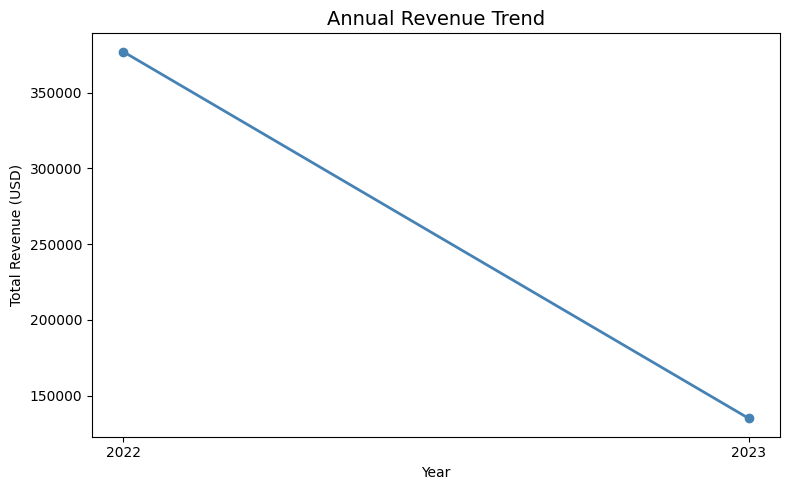

Chart 1 saved


In [11]:
plt.figure(figsize=(8, 5))
plt.plot(revenue_by_year['year'], revenue_by_year['total_revenue'],
         marker='o', color='steelblue', linewidth=2)
plt.title('Annual Revenue Trend', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.savefig('revenue_trend.png')
plt.show()
print("Chart 1 saved")

C:\Users\panka\AppData\Local\Temp\ipykernel_11160\3039895292.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='product', y='total_sales', palette='Blues_d')


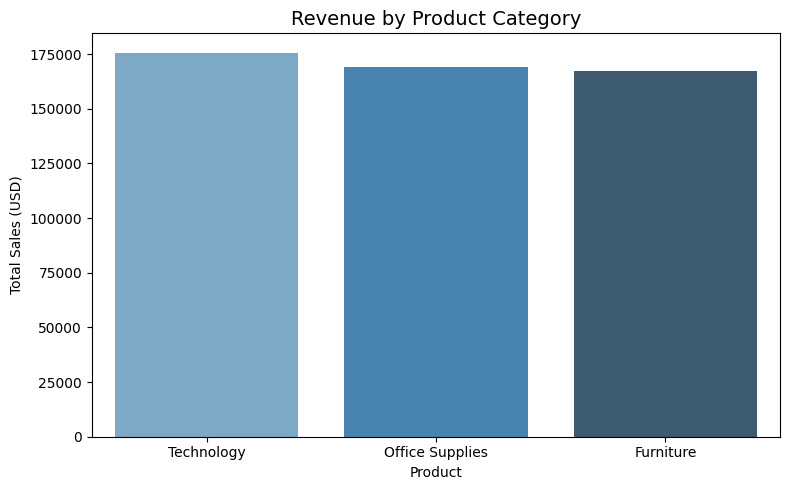

Chart 2 saved


In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=top_products, x='product', y='total_sales', palette='Blues_d')
plt.title('Revenue by Product Category', fontsize=14)
plt.xlabel('Product')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()
print("Chart 2 saved")

C:\Users\panka\AppData\Local\Temp\ipykernel_11160\1850115530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='region', y='total_sales', palette='muted')


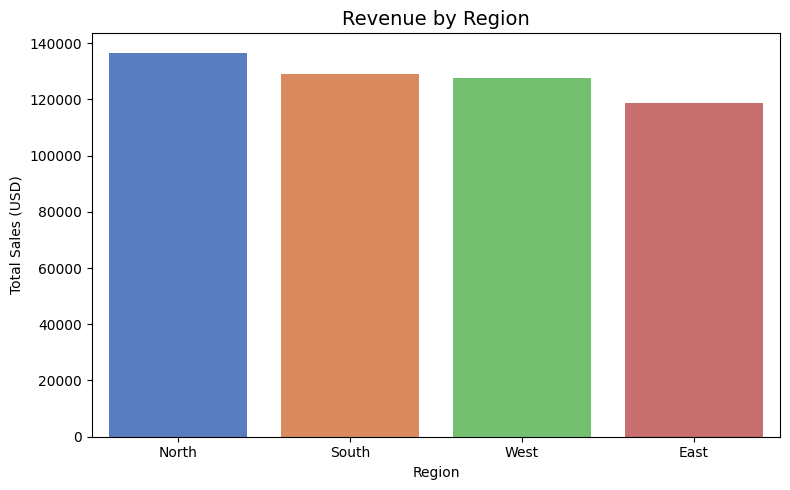

Chart 3 saved


In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, x='region', y='total_sales', palette='muted')
plt.title('Revenue by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.savefig('region_sales.png')
plt.show()
print("Chart 3 saved")

In [14]:
conn.close()
print("Database connection closed")

Database connection closed


In [15]:
print("=== PROJECT COMPLETE ===")
print(f"Total orders analysed: {len(df)}")
print(f"Total revenue: ${df['sales'].sum().round(2)}")
print(f"Most profitable region: {region_sales.iloc[0]['region']}")
print(f"Top product: {top_products.iloc[0]['product']}")
print("Files saved: sales.csv, sales.db, revenue_trend.png, category_sales.png, region_sales.png")

=== PROJECT COMPLETE ===
Total orders analysed: 500
Total revenue: $512081.56
Most profitable region: North
Top product: Technology
Files saved: sales.csv, sales.db, revenue_trend.png, category_sales.png, region_sales.png
